<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

In [ ]:
from bioMONAI.data import *
from bioMONAI.transforms import *
from fastai.vision.all import *
from monai.utils import set_determinism
set_determinism(0)
# from sklearn.model_selection import train_test_split

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Data

In [ ]:
bs, size = 8, 256
# arch = models.resnet34
path = Path('../../bioMONAI_0/_data/Thunder_20230308/nuevos_datos/dataset_5')
#path = Path('../_data/Babesia/')
path_x = path/'inputs'
path_y = path/'targets'

In [ ]:
from bioMONAI.core import get_target
get_target(path_y, same_filename=True)(path / '1.tiff')

Path('../../bioMONAI_0/_data/Thunder_20230308/nuevos_datos/dataset_5/targets/1.tiff')

### Look at training data

In [ ]:
from monai.transforms import ScaleIntensity
item_tfms = [ScaleIntensity(minv=0.0, maxv=1.0),
             RandCropND((16,128,128)),              
             ]

Setting-up type transforms pipelines
Found 28 items
2 datasets of sizes 23,5
Setting up Pipeline: BioImageBase.create
Setting up Pipeline: get_target.<locals>.generate_target_path -> BioImageBase.create

Building one sample
  Pipeline: BioImageBase.create
    starting from
      ../../bioMONAI_0/_data/Thunder_20230308/nuevos_datos/dataset_5/inputs/27.tif
    applying BioImageBase.create gives
      BioImageStack of size 1x16x2048x2048
  Pipeline: get_target.<locals>.generate_target_path -> BioImageBase.create
    starting from
      ../../bioMONAI_0/_data/Thunder_20230308/nuevos_datos/dataset_5/inputs/27.tif
    applying get_target.<locals>.generate_target_path gives
      ../../bioMONAI_0/_data/Thunder_20230308/nuevos_datos/dataset_5/targets/27.tif
    applying BioImageBase.create gives
      BioImageStack of size 1x16x2048x2048

Final sample: (BioImageStack([[[[61., 61., 59.,  ..., 34., 26., 28.],
          [62., 60., 55.,  ..., 29., 30., 28.],
          [64., 59., 62.,  ..., 35., 29

Setting affine, but the applied meta contains an affine. This will be overwritten.



Building one batch
Applying item_tfms to the first sample:
  Pipeline: ScaleIntensity -> RandCropND -- {'size': (16, 128, 128), 'lazy': False, 'p': 1.0} -> ToTensor
    starting from
      (BioImageStack of size 1x16x2048x2048, BioImageStack of size 1x16x2048x2048)
    applying ScaleIntensity gives
      (MetaTensor of size 1x16x2048x2048, MetaTensor of size 1x16x2048x2048)
    applying RandCropND -- {'size': (16, 128, 128), 'lazy': False, 'p': 1.0} gives
      (MetaTensor of size 1x16x128x128, MetaTensor of size 1x16x128x128)
    applying ToTensor gives
      (MetaTensor of size 1x16x128x128, MetaTensor of size 1x16x128x128)

Adding the next 3 samples

No before_batch transform to apply

Collating items in a batch

Applying batch_tfms to the batch built
  Pipeline: Tensor2BioImage -- {}
    starting from
      (MetaTensor of size 4x1x16x128x128, MetaTensor of size 4x1x16x128x128)
    applying Tensor2BioImage -- {} gives
      (BioImageStack of size 4x1x16x128x128, BioImageStack of si

Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.


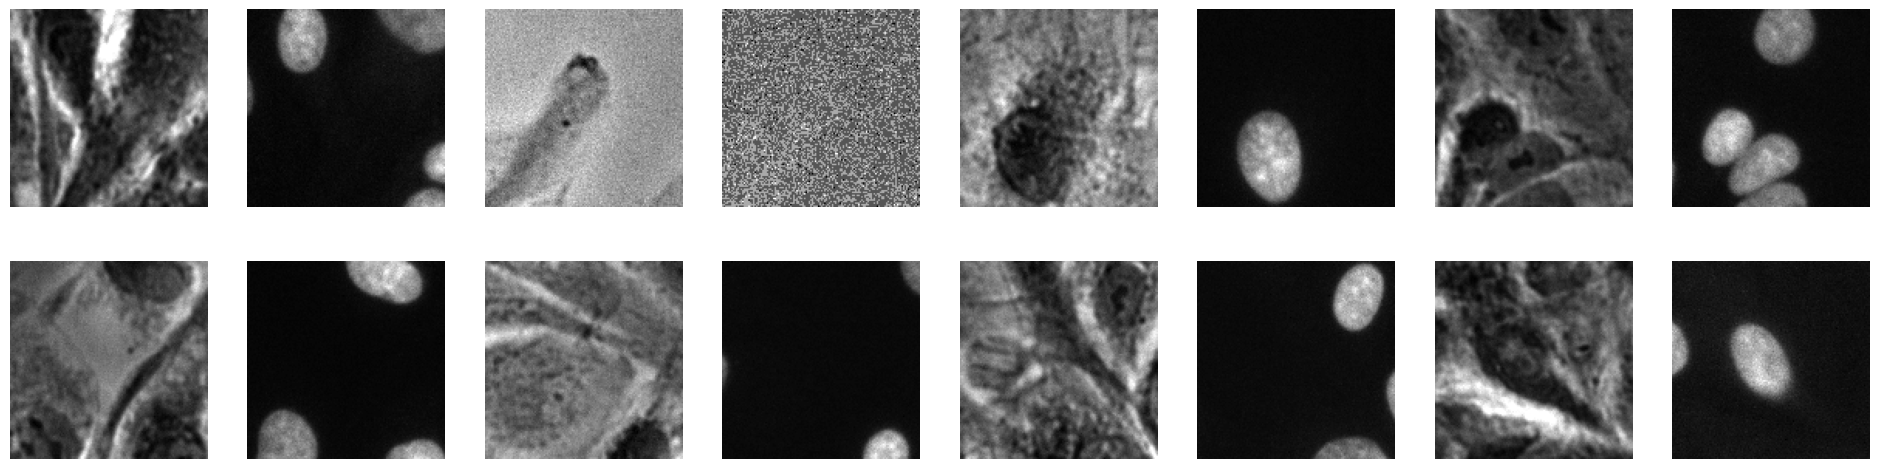

In [ ]:
from bioMONAI.core import get_target

dblock = DataBlock(blocks=(BioImageBlock(cls=BioImageStack), BioImageBlock(cls=BioImageStack)),
                   get_items=get_image_files,
                   get_y=get_target(path_y, same_filename=True),
                   splitter=RandomSplitter(valid_pct=0.2),
                   item_tfms=item_tfms,
                  )

dblock.summary(path_x)

dls = dblock.dataloaders(path_x, bs=bs)
dls.show_batch(max_n=8, cmap='gray')

In [ ]:
inputs, targets = dls.one_batch()
print(f'Inputs shape: {inputs.shape}, Targets shape: {targets.shape}')

# Asegúrate de que las dimensiones de entrada y salida sean las mismas
assert inputs.shape == targets.shape, "Dimensiones de entrada y salida no coinciden"

Inputs shape: torch.Size([8, 1, 16, 128, 128]), Targets shape: torch.Size([8, 1, 16, 128, 128])


Setting affine, but the applied meta contains an affine. This will be overwritten.


In [ ]:
# training and validation
len(dls.train_ds.items), len(dls.valid_ds.items)

(23, 5)

### Create and train a 2D model

In [ ]:
from monai.networks.nets import BasicUNet, AttentionUnet, DynUNet, UNet, BasicUNet
from bioMONAI.nets import DnCNN

In [ ]:
# model = UNet(spatial_dims=2, in_channels=1, out_channels=1, channels=(16, 32, 64, 128, 256),strides=(2, 2, 2, 2), num_res_units=2).model
# model = UNet(spatial_dims=3, in_channels=1, out_channels=1, channels=(8, 16,32),strides=(1,1), num_res_units=1).model
# model = AttentionUnet(spatial_dims=2, in_channels=1, out_channels=1, channels=(16, 32, 64),strides=(1, 1))
#model = DynUNet(spatial_dims=2, in_channels=1, out_channels=1, strides=(1, 2, 2),kernel_size=(3, 3, 3), upsample_kernel_size=(2, 2), res_block=True) # it tends to create hot pixels
model = BasicUNet(spatial_dims=3, in_channels=1, out_channels=1)

BasicUNet features: (32, 32, 64, 128, 256, 32).


In [ ]:
model

BasicUNet(
  (conv_0): TwoConv(
    (conv_0): Convolution(
      (conv): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (adn): ADN(
        (N): InstanceNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
        (D): Dropout(p=0.0, inplace=False)
        (A): LeakyReLU(negative_slope=0.1, inplace=True)
      )
    )
    (conv_1): Convolution(
      (conv): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (adn): ADN(
        (N): InstanceNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
        (D): Dropout(p=0.0, inplace=False)
        (A): LeakyReLU(negative_slope=0.1, inplace=True)
      )
    )
  )
  (down_1): Down(
    (max_pooling): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (convs): TwoConv(
      (conv_0): Convolution(
        (conv): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (adn): ADN(
 

In [ ]:
tensor_aleatorio = torch.rand(8,1,16,128, 128).to('cuda')

model(tensor_aleatorio).shape

torch.Size([8, 1, 16, 128, 128])

In [ ]:
from bioMONAI.losses import CombinedLoss
loss_func = mse #CombinedLoss()

In [ ]:
from bioMONAI.losses import SSIMMetric

metrics = [mae, mse]

In [ ]:
# learn = Learner(dls, model, loss_func=loss_func, opt_func=ranger, metrics=nn.L1Loss)

learn = Learner(dls, model, loss_func=loss_func, metrics=metrics, cbs=ShowGraphCallback())

In [ ]:
learn.summary()

Setting affine, but the applied meta contains an affine. This will be overwritten.


BasicUNet (Input shape: 8 x 1 x 16 x 128 x 128)
Layer (type)         Output Shape         Param #    Trainable 
                     8 x 32 x 16 x 128 x 
Conv3d                                    896        True      
InstanceNorm3d                            64         True      
Dropout                                                        
LeakyReLU                                                      
Conv3d                                    27680      True      
InstanceNorm3d                            64         True      
Dropout                                                        
LeakyReLU                                                      
____________________________________________________________________________
                     8 x 32 x 8 x 64 x 6 
MaxPool3d                                                      
Conv3d                                    27680      True      
InstanceNorm3d                            64         True      
Dropout                

In [ ]:
# lr = learn.lr_find(suggest_funcs=(minimum, steep, valley, slide))
lr = learn.lr_find(suggest_funcs=(valley))
print(lr)

OutOfMemoryError: CUDA out of memory. Tried to allocate 64.00 MiB (GPU 0; 7.78 GiB total capacity; 6.03 GiB already allocated; 41.69 MiB free; 6.10 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

In [ ]:
lr = float('%.1g'%(lr))
print(lr)

0.001


epoch,train_loss,valid_loss,mae,mse,time
0,0.004272,0.005650,0.044280,0.005650,00:22
1,0.004270,0.005678,0.043937,0.005678,00:23
2,0.004576,0.005705,0.043927,0.005705,00:23
3,0.004360,0.005682,0.044171,0.005682,00:22
4,0.004098,0.005646,0.044278,0.005646,00:22
5,0.004252,0.005596,0.044206,0.005596,00:21
6,0.004242,0.005510,0.043788,0.005510,00:19
7,0.004017,0.005464,0.043148,0.005464,00:19
8,0.004094,0.005446,0.042713,0.005446,00:22
9,0.004182,0.005435,0.042757,0.005435,00:20


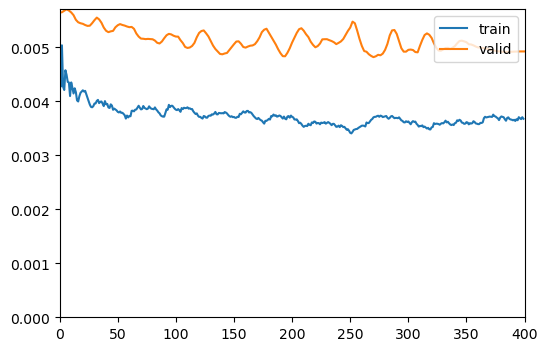

In [ ]:
learn.fit_flat_cos(200,0.001)

Setting affine, but the applied meta contains an affine. This will be overwritten.


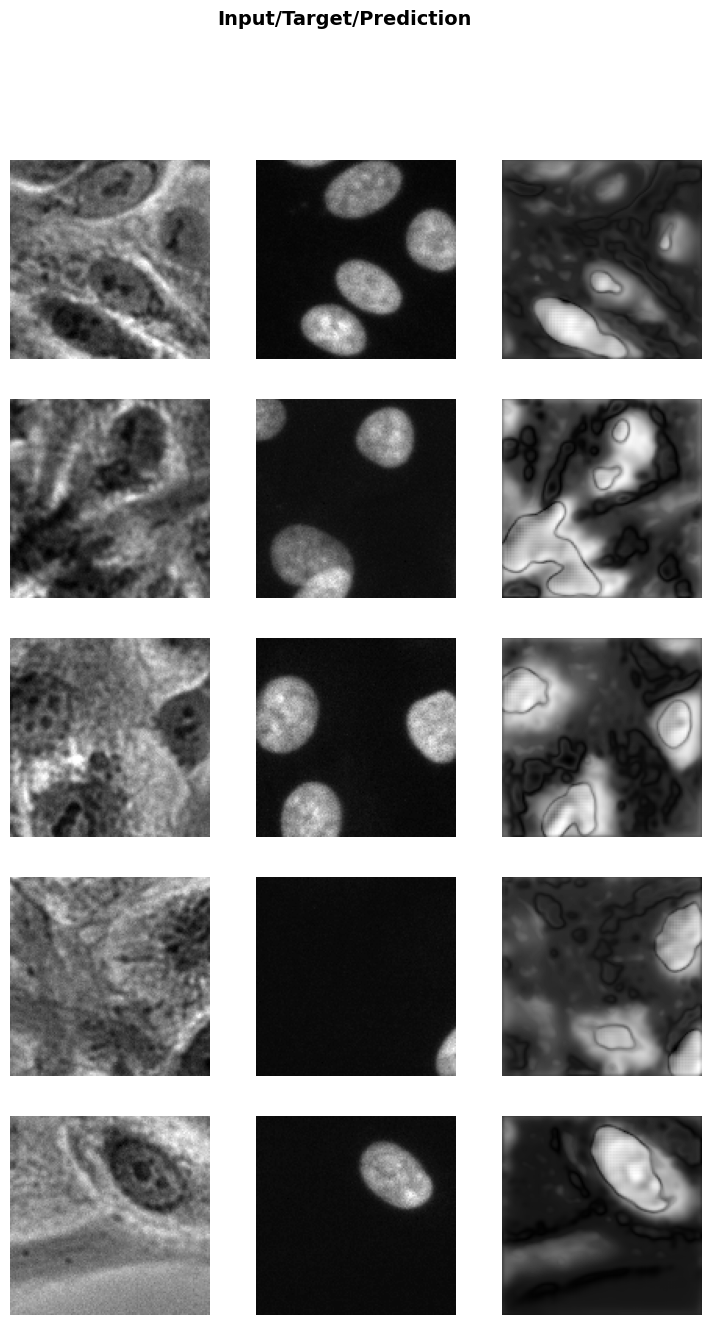

In [ ]:
learn.show_results(cmap='gray')

In [ ]:
# learn.save('tmp-model')

### Test data 
Evaluate the performance of the selected model on unseen data.
It’s important to not touch this data until you have fine tuned your model to get an unbiased evaluation!

### Export learner

In [ ]:
# store_variables(pkl_fn='vars.pkl', size=size, reorder=reorder,  resample=resample)

In [ ]:
# learn.export('______.pkl')